In [2]:
import tensorflow as tf

In [3]:
(x_train, y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
# reshaping the training and testing dataset
x_train=x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test=x_test.reshape(x_test.shape[0], 28, 28, 1)

In [7]:
# Neural networks work best with floating-point numbers rather than integers, so we are converting the type to float here
x_train = x_train.astype('float32')
x_test=x_test.astype('float32')

In [8]:
# normalize the pixel values to the range [0, 1] by dividing by 255:
x_train /= 255
x_test /= 255
input_shape=(28,28,1)


In [62]:
print(x_test[0].min(), x_test[0].max())

0.0 1.0


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), activation='relu',input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))
          
          

In [64]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=10)
              

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8966 - loss: 0.3446
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9785 - loss: 0.0685
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9864 - loss: 0.0443
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9898 - loss: 0.0333
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9928 - loss: 0.0234
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9940 - loss: 0.0190
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9946 - loss: 0.0155
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9961 - loss: 0.0122
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9959 - loss: 0.0114
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9969 - loss: 0.0092


In [65]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 28)          │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 13, 13, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 4732)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         605,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,822,184 (6.95 MB)

 Trainable params: 607,394 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,214,790 (4.63 MB)

In [67]:
y_predict=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 


In [68]:
# To visualize the convolutional layer output
from tensorflow.keras.models import Model
# building the model with input and output of the convolutional layer
conv_layer_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[0].output   # first Conv2D layer
)

In [74]:

# 3. Get feature maps
img = x_test[6900].reshape(1, 28, 28, 1)
feature_maps = conv_layer_model.predict(img)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


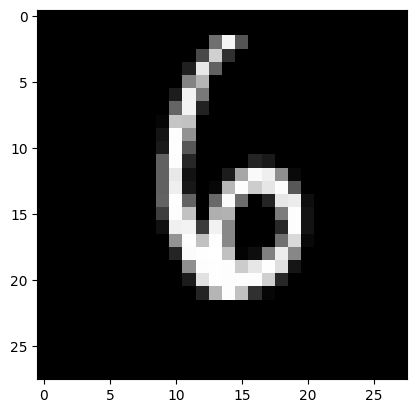

In [76]:
plt.imshow(x_test[6900], cmap='gray')

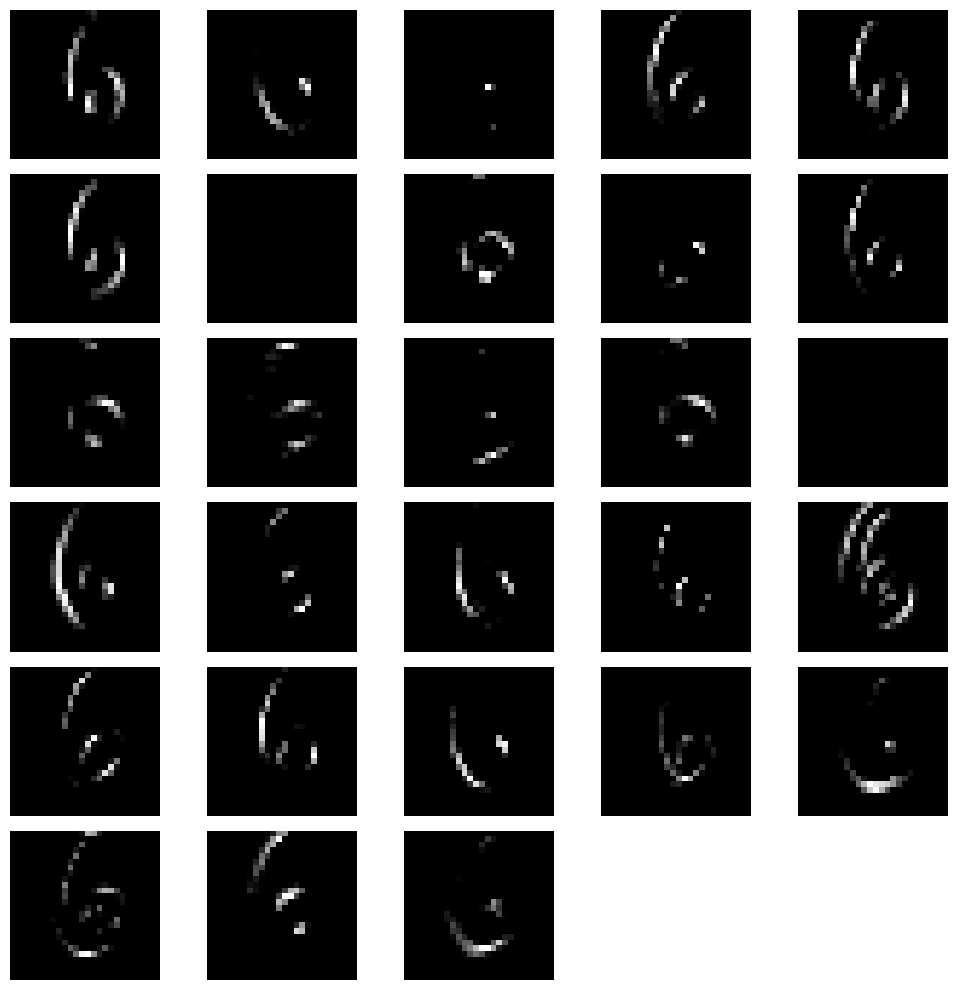

In [77]:
import numpy as np

plt.figure(figsize=(10,10))

for i in range(feature_maps.shape[-1]):
    fmap = feature_maps[0, :, :, i]
    
    # CRUCIAL: normalize each feature map
    fmap -= fmap.min()
    fmap /= (fmap.max() + 1e-8)
    
    plt.subplot(6, 5, i+1)
    plt.imshow(fmap, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [78]:
print(feature_maps.min(), feature_maps.max())

0.0 1.0


0.0 1.0


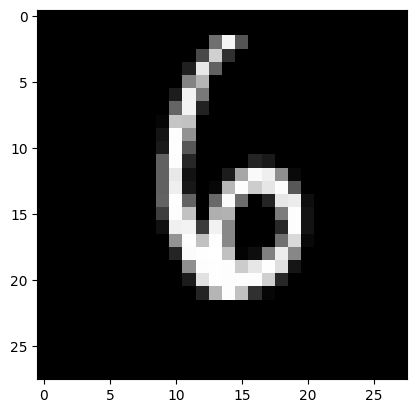

In [79]:
print(img.min(), img.max())
plt.imshow(img[0, :, :, 0], cmap='gray')